# Ejemplo de Potencial de Yukawa en 2D

Este notebook demuestra cómo:
1. Configurar y ejecutar una simulación 2D de un paquete de ondas gaussiano bajo un potencial de Yukawa.
2. Calcular y graficar observables 2D como la densidad de probabilidad y la corriente de probabilidad.
3. Graficar la evolución temporal de los valores esperados.
4. Generar una animación de la densidad de probabilidad.

In [1]:
import sys
sys.path.append('..')
import os
import numpy as np
import matplotlib.pyplot as plt
from dirac_solver import (
    Grid, 
    GaussianPacket, 
    ConstantSpinor, 
    DiracProblemBuilder, 
    DiracSolver,
    YukawaPotential
)
from dirac_solver.storage import HDF5Storage, create_animation
from dirac_solver.observables import Observables
from dirac_solver.core import _core

## 1. Configuración de la Simulación

In [2]:
# --- Parámetros de la simulación ---
shape = (100, 100)
spacing = (0.1, 0.1)
grid = Grid(shape, spacing)
time_step = 0.002
total_time = 10.0

# --- Estado Inicial: Paquete Gaussiano ---
# Momento en x e y
constant_spinor = ConstantSpinor(momentum=[4, 1, 0])
# Centro desplazado para ver el movimiento
initial_state = GaussianPacket(constant_spinor, center=[-2, -2, 0], spatial_width=1.0)

# --- Potencial de Yukawa ---
# V(r) = -V0 * exp(-a*r) / r
strength = 5.0 # V0
interaction_range = 2.0 # a
potential = YukawaPotential(strength=strength, range=interaction_range).core_potential

# --- Condiciones de Borde ---
boundary_condition = _core.PeriodicBoundary()

# --- Construcción del Problema ---
problem = DiracProblemBuilder() \
    .set_grid(grid) \
    .set_initial_state(initial_state) \
    .set_potential(potential) \
    .set_boundary_condition(boundary_condition) \
    .set_time_parameters(time_step, total_time) \
    .build()

solver = DiracSolver(problem)

DiracSolver inicializado con el motor C++ 'FDTDLeapfrogIntegrator'.


## 2. Ejecución de la Simulación y Cálculo de Observables

In [3]:
# --- Archivos de salida ---
output_dir = 'output'
os.makedirs(output_dir, exist_ok=True)
hdf5_path = os.path.join(output_dir, 'yukawa_2d.hdf5')
animation_path = os.path.join(output_dir, 'yukawa_2d.gif')

# --- Inicializar manejadores ---
storage = HDF5Storage(hdf5_path, problem)
observables = Observables(solver)

# --- Ejecutar la simulación ---
# save_every_n_steps=10 para no generar demasiados datos
solver.run_simulation(
    storage_handler=storage,
    observables_handler=observables,
    save_every_n_steps=10
)

HDF5Storage inicializado. Guardando datos en: output/yukawa_2d.hdf5
Ejecutando simulación por 1000 pasos...
Guardando snapshot inicial (t=0.0).
  Paso 10/1000 completado.
  Paso 20/1000 completado.
  Paso 30/1000 completado.
  Paso 40/1000 completado.
  Paso 50/1000 completado.
  Paso 60/1000 completado.
  Paso 70/1000 completado.
  Paso 80/1000 completado.
  Paso 90/1000 completado.
  Paso 100/1000 completado.
  Paso 110/1000 completado.
  Paso 120/1000 completado.
  Paso 130/1000 completado.
  Paso 140/1000 completado.
  Paso 150/1000 completado.
  Paso 160/1000 completado.
  Paso 170/1000 completado.
  Paso 180/1000 completado.
  Paso 190/1000 completado.
  Paso 200/1000 completado.
  Paso 210/1000 completado.
  Paso 220/1000 completado.
  Paso 230/1000 completado.
  Paso 240/1000 completado.
  Paso 250/1000 completado.
  Paso 260/1000 completado.
  Paso 270/1000 completado.
  Paso 280/1000 completado.
  Paso 290/1000 completado.
  Paso 300/1000 completado.
  Paso 310/1000 completad

## 3. Visualización de Valores Esperados

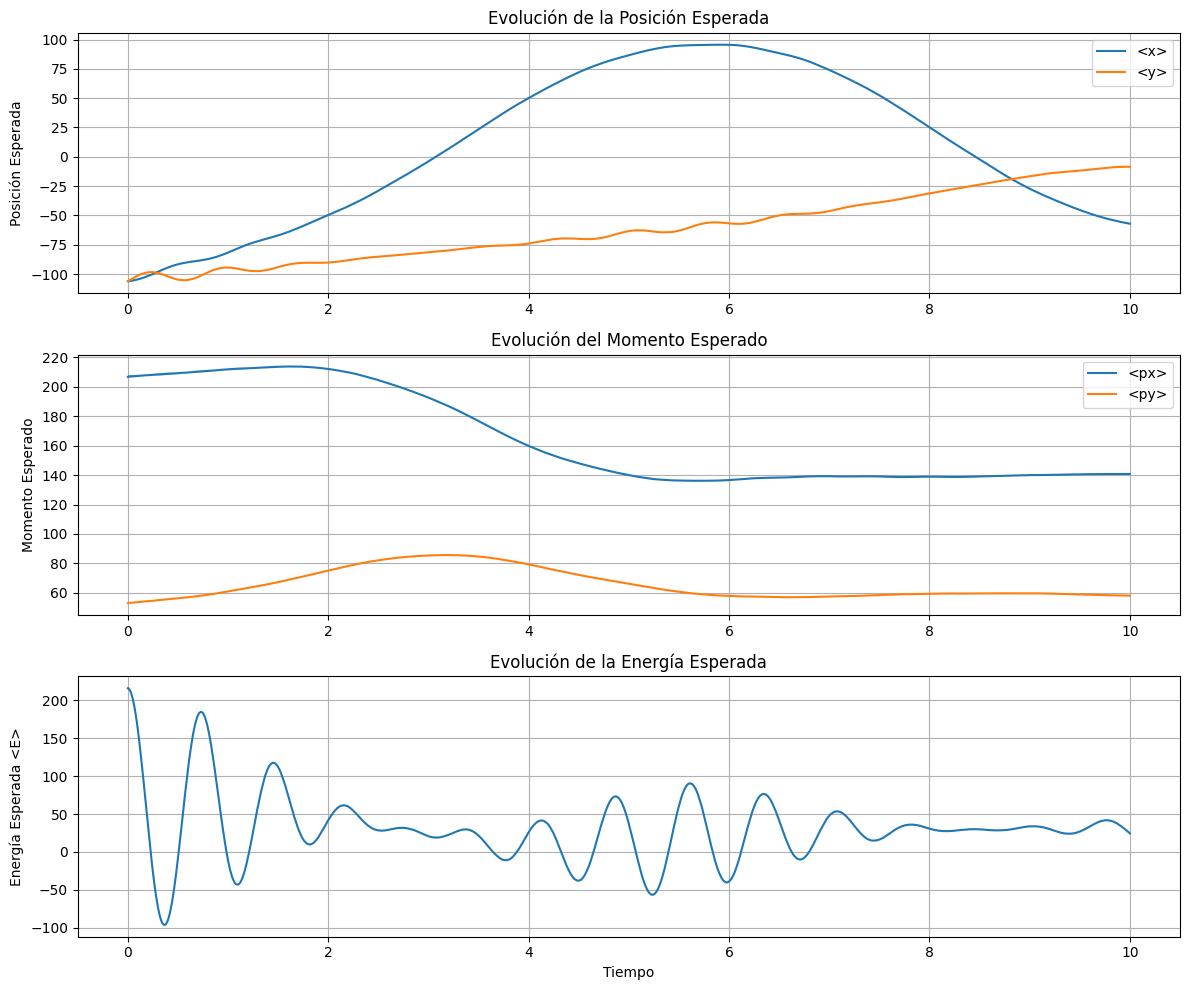

In [4]:
time = observables.get_history('time')
expected_pos = observables.get_history('expected_position')
expected_mom = observables.get_history('expected_momentum')
expected_energy = observables.get_history('expected_energy')

plt.figure(figsize=(12, 10))

# Posición Esperada X e Y
plt.subplot(3, 1, 1)
plt.plot(time, expected_pos[:, 0], label='<x>')
plt.plot(time, expected_pos[:, 1], label='<y>')
plt.ylabel('Posición Esperada')
plt.legend()
plt.grid(True)
plt.title('Evolución de la Posición Esperada')

# Momento Esperado X e Y
plt.subplot(3, 1, 2)
plt.plot(time, expected_mom[:, 0], label='<px>')
plt.plot(time, expected_mom[:, 1], label='<py>')
plt.ylabel('Momento Esperado')
plt.legend()
plt.grid(True)
plt.title('Evolución del Momento Esperado')

# Energía Esperada
plt.subplot(3, 1, 3)
plt.plot(time, expected_energy)
plt.ylabel('Energía Esperada <E>')
plt.xlabel('Tiempo')
plt.grid(True)
plt.title('Evolución de la Energía Esperada')

plt.tight_layout()
plt.show()

## 4. Visualización 2D: Densidad y Corriente de Probabilidad

Mostramos el estado final de la simulación.

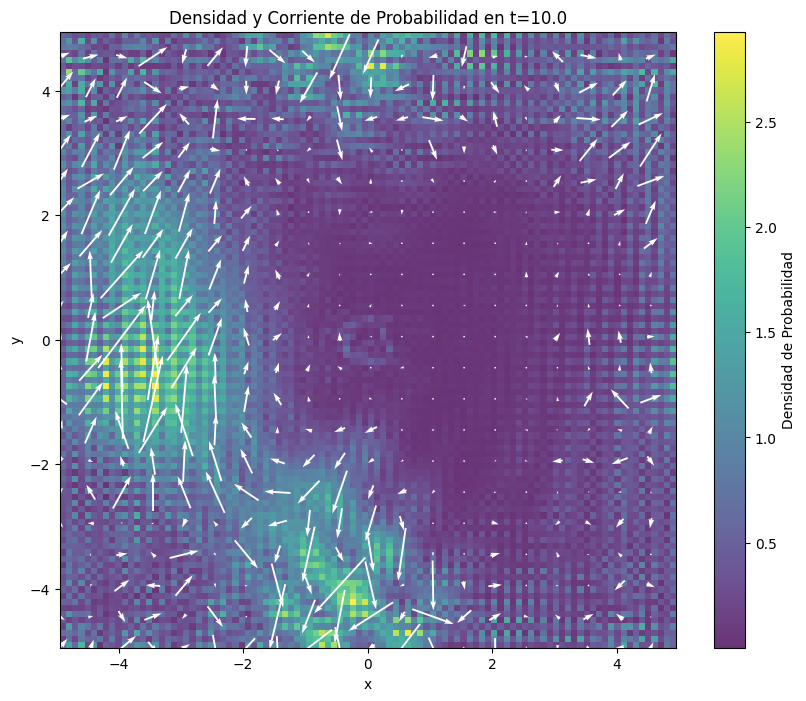

In [5]:
# Recuperamos los últimos datos guardados en el historial
last_prob_density = observables.get_history('probability_density')[-1]
last_prob_current = observables.get_history('probability_current')[-1]

# Reshape para la malla 2D
rho_grid = last_prob_density.reshape(shape)
jx_grid = last_prob_current[:, 0].reshape(shape)
jy_grid = last_prob_current[:, 1].reshape(shape)

# Coordenadas para graficar
x = np.linspace(grid.origin[0], grid.origin[0] + (shape[0]-1)*spacing[0], shape[0])
y = np.linspace(grid.origin[1], grid.origin[1] + (shape[1]-1)*spacing[1], shape[1])
X, Y = np.meshgrid(x, y, indexing='ij')

plt.figure(figsize=(10, 8))

# Graficar densidad de probabilidad como mapa de calor
plt.imshow(rho_grid.T, origin='lower', extent=[x[0], x[-1], y[0], y[-1]], cmap='viridis', alpha=0.8)
plt.colorbar(label='Densidad de Probabilidad')

# Graficar corriente de probabilidad como vectores (quiver)
# Submuestreamos para que no se vea muy denso el gráfico de flechas
skip = 5
plt.quiver(X[::skip, ::skip], Y[::skip, ::skip], 
           jx_grid[::skip, ::skip], jy_grid[::skip, ::skip], 
           color='white', pivot='mid', scale=None)

plt.title(f'Densidad y Corriente de Probabilidad en t={total_time}')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## 5. Generación de la Animación

In [7]:
print(f"Generando animación a partir de {hdf5_path}...")
create_animation(hdf5_path, animation_path, interval=100)
print(f"Animación guardada en: {animation_path}")

Generando animación a partir de output/yukawa_2d.hdf5...
Animation saved to output/yukawa_2d.gif
Animación guardada en: output/yukawa_2d.gif
